# Evaluierung des MixUp-Metrik-Modells auf TextComplexityDE (Naderi et al., 2019)
### Masterarbeit: Automatische Übersetzung von Alltagssprache (AS) in Leichte Sprache (LS)

Dieses Notebook evaluiert das trainierte **MixUp-Regressormodell** auf dem Benchmark **TextComplexityDE** (1.000 deutsche Wikipedia-Sätze mit menschlichen Urteilen von Deutschlernenden).

In [1]:
import os
import sys
import json
import urllib.request
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, kendalltau
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Styling
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

# Arbeitsverzeichnis robust auf Projekt-Root setzen
while not (os.path.exists(".git") or os.path.exists("data")) and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir("..")

if not os.path.exists("data"):
        if os.path.exists(candidate):
            os.chdir(candidate)

print("Arbeitsverzeichnis:", os.getcwd())


Arbeitsverzeichnis: /home/fiete/master-thesis


## 1. TextComplexityDE Benchmark-Daten laden

Einlesen der vorberechneten Modellvorhersagen auf den 1.000 Wikipedia-Sätzen.

In [3]:
# ==============================================================================
# 1. ERGEBNIS-DATEN EINLESEN (TextComplexityDE Benchmark)
# ==============================================================================
CSV_PATH = "results/evaluation/textcomplexityde_eval.csv"
if not os.path.exists(CSV_PATH):
    CSV_PATH = "../../../results/evaluation/textcomplexityde_eval.csv"

df_tc = pd.read_csv(CSV_PATH)
print(f"Ergebnisse erfolgreich geladen: {len(df_tc)} Zeilen aus {CSV_PATH}")
display(df_tc)


## 2. Statistische Korrelationen & Performanz-Metriken

In [6]:
preds = df_tc["pred_simplicity"]

# Korrelationen
r_comp, p_r_comp = pearsonr(preds, df_tc["MOS_Complexity"])
rho_comp, p_rho_comp = spearmanr(preds, df_tc["MOS_Complexity"])
tau_comp, _ = kendalltau(preds, df_tc["MOS_Complexity"])

rho_und, _ = spearmanr(preds, df_tc["MOS_Understandability"])
rho_lex, _ = spearmanr(preds, df_tc["MOS_Lexical_difficulty"])

# Fehlermaße
mae = mean_absolute_error(df_tc["Human_Simplicity_Norm"], preds)
mse = mean_squared_error(df_tc["Human_Simplicity_Norm"], preds)
r2 = r2_score(df_tc["Human_Simplicity_Norm"], preds)

summary_data = {
    "Metrik": [
        "Pearson r (vs. MOS Komplexität)",
        "Spearman rho (vs. MOS Komplexität)",
        "Kendall tau (vs. MOS Komplexität)",
        "Spearman rho (vs. MOS Verständlichkeit)",
        "Spearman rho (vs. MOS Lexikalische Schwierigkeit)",
        "MAE (auf normalisierter Einfachheit)",
        "MSE (auf normalisierter Einfachheit)",
        "R² Score (auf normalisierter Einfachheit)"
    ],
    "Wert": [
        r_comp,
        rho_comp,
        tau_comp,
        rho_und,
        rho_lex,
        mae,
        mse,
        r2
    ]
}

res_df = pd.DataFrame(summary_data)
display(res_df.style.format({"Wert": "{:.4f}"}))


,Metrik,Wert
0,Pearson r (vs. MOS Komplexität),-0.5983
1,Spearman rho (vs. MOS Komplexität),-0.6574
2,Kendall tau (vs. MOS Komplexität),-0.4778
3,Spearman rho (vs. MOS Verständlichkeit),-0.5453
4,Spearman rho (vs. MOS Lexikalische Schwierigkeit),-0.5789
5,MAE (auf normalisierter Einfachheit),0.4535
6,MSE (auf normalisierter Einfachheit),0.2378
7,R² Score (auf normalisierter Einfachheit),-5.1451


## 3. Visualisierungen

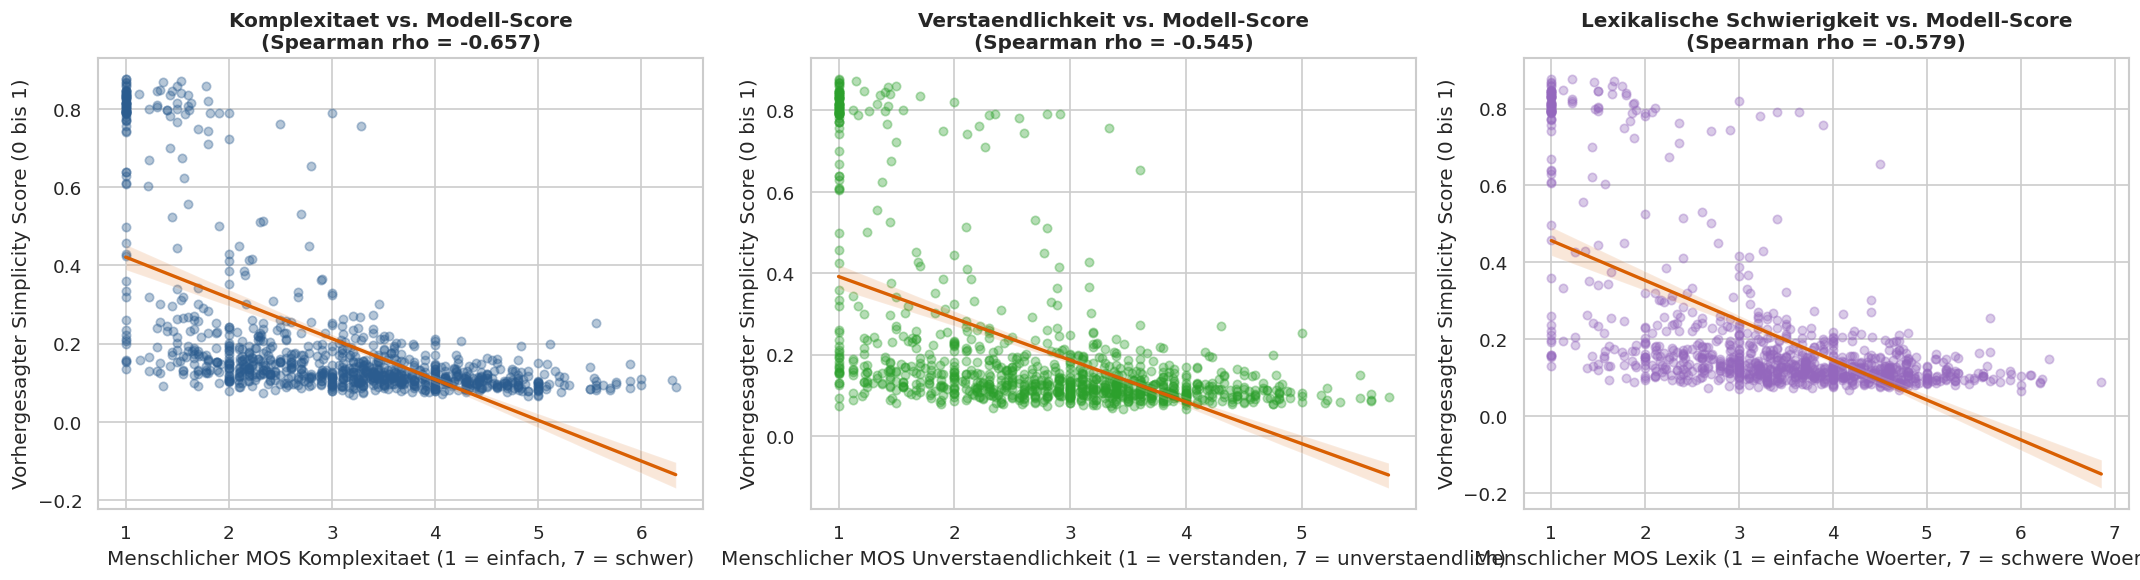

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Complexity
sns.regplot(
    data=df_tc, x="MOS_Complexity", y="pred_simplicity",
    ax=axes[0], color="#2b5c8f", scatter_kws={"alpha": 0.35, "s": 25}, line_kws={"color": "#d95f02", "lw": 2}
)
axes[0].set_title(f"Komplexitaet vs. Modell-Score\n(Spearman rho = {rho_comp:.3f})", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Menschlicher MOS Komplexitaet (1 = einfach, 7 = schwer)")
axes[0].set_ylabel("Vorhergesagter Simplicity Score (0 bis 1)")

# 2. Understandability
sns.regplot(
    data=df_tc, x="MOS_Understandability", y="pred_simplicity",
    ax=axes[1], color="#2ca02c", scatter_kws={"alpha": 0.35, "s": 25}, line_kws={"color": "#d95f02", "lw": 2}
)
axes[1].set_title(f"Verstaendlichkeit vs. Modell-Score\n(Spearman rho = {rho_und:.3f})", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Menschlicher MOS Unverstaendlichkeit (1 = verstanden, 7 = unverstaendlich)")
axes[1].set_ylabel("Vorhergesagter Simplicity Score (0 bis 1)")

# 3. Lexical Difficulty
sns.regplot(
    data=df_tc, x="MOS_Lexical_difficulty", y="pred_simplicity",
    ax=axes[2], color="#9467bd", scatter_kws={"alpha": 0.35, "s": 25}, line_kws={"color": "#d95f02", "lw": 2}
)
axes[2].set_title(f"Lexikalische Schwierigkeit vs. Modell-Score\n(Spearman rho = {rho_lex:.3f})", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Menschlicher MOS Lexik (1 = einfache Woerter, 7 = schwere Woerter)")
axes[2].set_ylabel("Vorhergesagter Simplicity Score (0 bis 1)")

plt.tight_layout()
os.makedirs("results/plots", exist_ok=True)
plt.savefig("results/plots/textcomplexityde_mixup_scatter_3panel.png", bbox_inches="tight", dpi=300)
plt.show()


/tmp/ipykernel_2253327/380460717.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


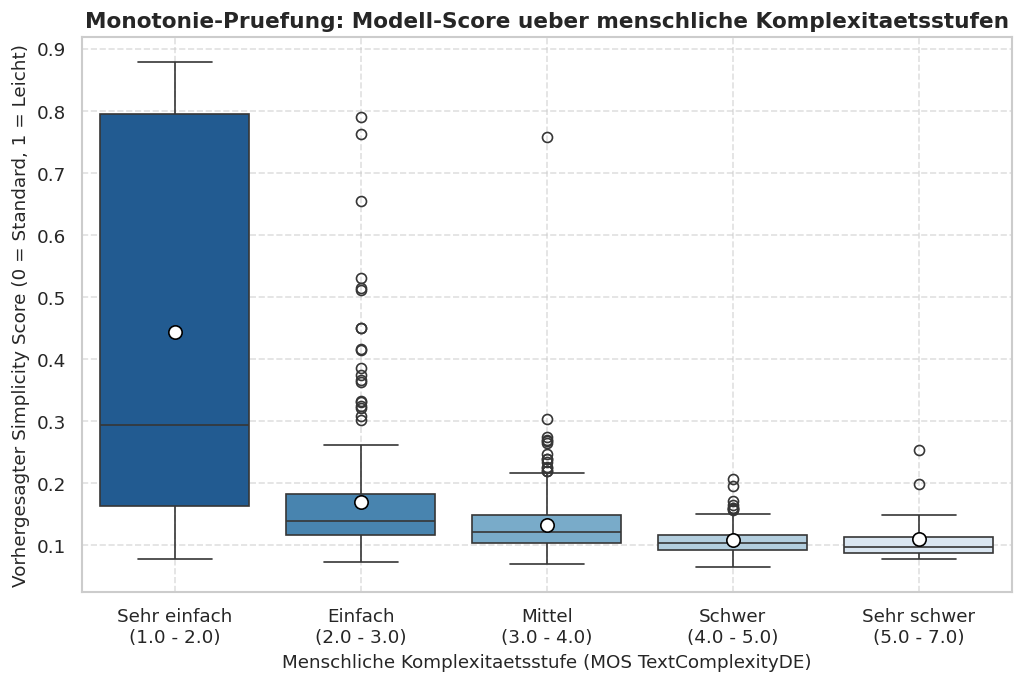

In [8]:
# Boxplots nach Komplexitäts-Intervallen
bins = [1.0, 2.0, 3.0, 4.0, 5.0, 7.0]
labels = ["Sehr einfach\n(1.0 - 2.0)", "Einfach\n(2.0 - 3.0)", "Mittel\n(3.0 - 4.0)", "Schwer\n(4.0 - 5.0)", "Sehr schwer\n(5.0 - 7.0)"]
df_tc["Complexity_Category"] = pd.cut(df_tc["MOS_Complexity"], bins=bins, labels=labels, include_lowest=True)

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_tc, x="Complexity_Category", y="pred_simplicity",
    palette="Blues_r", showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
)
plt.title("Monotonie-Pruefung: Modell-Score ueber menschliche Komplexitaetsstufen", fontsize=13, fontweight="bold")
plt.xlabel("Menschliche Komplexitaetsstufe (MOS TextComplexityDE)", fontsize=11)
plt.ylabel("Vorhergesagter Simplicity Score (0 = Standard, 1 = Leicht)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)
plt.savefig("results/plots/textcomplexityde_mixup_boxplots.png", bbox_inches="tight", dpi=300)
plt.show()


## 4. Detail- & Ausreißeranalyse

In [9]:
df_tc["Abs_Error"] = (df_tc["Human_Simplicity_Norm"] - df_tc["pred_simplicity"]).abs()

print("=== Top 5 Saetze: Mensch urteilt EINFACH, Modell urteilt SCHWER ===")
fp = df_tc.sort_values(by="pred_simplicity").head(5)
for idx, row in fp.iterrows():
    print(f"• Text: {row['Sentence']}")
    print(f"  MOS Komplexitaet: {row['MOS_Complexity']:.2f} | Modell Score: {row['pred_simplicity']:.4f}\n")

print("=== Top 5 Saetze: Mensch urteilt SCHWER, Modell urteilt EINFACH ===")
fn = df_tc.sort_values(by="pred_simplicity", ascending=False).head(5)
for idx, row in fn.iterrows():
    print(f"• Text: {row['Sentence']}")
    print(f"  MOS Komplexitaet: {row['MOS_Complexity']:.2f} | Modell Score: {row['pred_simplicity']:.4f}\n")


=== Top 5 Saetze: Mensch urteilt EINFACH, Modell urteilt SCHWER ===
• Text: Hierfür wird das im Untergrund erhitzte Wasser genutzt, um eine Dampfturbine anzutreiben Der geschlossene Kreislauf im Zirkulationssystem steht so unter Druck, dass ein Sieden des eingepressten Wassers verhindert wird und der Dampf erst an der Turbine entsteht (Flash-Verdampfung).
  MOS Komplexitaet: 4.90 | Modell Score: 0.0657

• Text: In einer verbindlichen Erklärung aus dem Jahr 2010 haben sich die Parlamentarier mit der Kommission geeinigt, den geltenden europarechtlichen Vorschriften eine Interpretationshilfe zu geben, sodass in Zukunft auf Anstoß des Parlamentes die Kommission innerhalb von zwölf Monaten einen Gesetzentwurf vorlegen oder innerhalb von drei Monaten detailliert begründen muss, warum sie es nicht macht.
  MOS Komplexitaet: 5.00 | Modell Score: 0.0673

• Text: Studien belegen, dass die Frage, ob Kinder aus der Situation einen Nachteil oder auch einen Vorteil beziehen, nicht mit Ja oder Nei